# 04a · A 1-D CNN on the raw curve (keeping magnitude)

*The companion to notebook 04: same task, but a representation that keeps the scale.*

> ⏱ **Runtime:** ~15 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** AFM grid (load–depth curves)

### 🎯 What you'll learn
1. what a **1-D convolution** is (a filter sliding along a sequence),
2. how a 1-D CNN reads a load–depth curve **directly**, without turning it into an image,
3. why keeping **magnitude** lets it beat the scale-invariant GAF CNN of notebook 04,
4. the takeaway once more: **match the representation to what separates the classes**.

### 🧭 What you need to know first
- Notebook **04** (the GAF/2-D CNN and the shape-vs-scale lesson).
- PyTorch basics from notebooks 04/10.

> 🔁 **The point of this notebook.** In notebook 04 the GAF **threw away magnitude**, so a simple
> feature model (PCA+RF, ~0.90) beat the CNN (~0.70) on a task where the two phases differ mostly in
> *level*. Here we feed the **raw curve** to a **1-D CNN**, which **keeps** that level information — and
> it should close the gap. Same task, better-matched input.

### Step 0 — set-up

Run the cell below first. In Jupyter you run a cell by clicking it and pressing **Shift + Enter**.

> 🟢 **On Google Colab** this cell also clones the repo and installs a few extra packages — it takes about a minute the first time. On your own machine (after `pip install -r requirements.txt`) it's instant.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py` — that means the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


> 🧠 **1-D convolution** — a small filter (here 5 numbers wide) that slides along the curve looking for a local pattern — the sequence analogue of the 2-D filters that slide over an image.

In [2]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
torch.manual_seed(0); np.random.seed(0)

## 1 · The same curves and labels as notebook 04

Load–depth curves, hard vs soft phase at the median hardness — identical to notebook 04 so the
comparison is fair.

> 🔑 **The crucial difference from 04.** We standardise **per depth-channel across the whole dataset**
> (each depth's mean/spread), which *keeps* the fact that some curves sit higher than others. The GAF in
> notebook 04 instead rescaled **each curve on its own**, erasing exactly that information.

> ✅ **When you run the next cell, you should see:** the curve matrix shape and hard/soft counts — the same dataset as notebook 04.

In [3]:
afm = mm.load_afm_grid()
Craw = afm["load_mN"].copy()                      # (n, 64): load vs depth
keep = np.isfinite(Craw).mean(0) > 0.5
Craw = SimpleImputer(strategy="median").fit_transform(Craw[:, keep])
ok = Craw.std(1) > 1e-6
Craw = Craw[ok]
y = (afm["H"][ok] > np.median(afm["H"][ok])).astype(int)

# Per-channel standardisation KEEPS inter-curve magnitude (unlike the GAF's per-curve rescale).
Cs = StandardScaler().fit_transform(Craw)
print("curves:", Cs.shape, " hard/soft:", int(y.sum()), int((1 - y).sum()))

curves: (6554, 55)  hard/soft: 3277 3277


## 2 · A small 1-D CNN

Two `Conv1d` blocks slide filters along the 64-point curve, then a linear head predicts the phase.

> 🧠 **channel** — a Conv1d input has shape (batch, channels, length). Our curve is a single channel, so channels = 1 — like a grayscale image has one colour channel.

> ✅ **When you run the next cell, you should see:** the parameter count (a few thousand) — a small model, trained on CPU in seconds.

In [4]:
Xtr, Xte, ytr, yte = train_test_split(Cs, y, test_size=0.3, stratify=y, random_state=0)

def loader(X, yy, bs=32, shuffle=False):
    # add a channel dimension: (n, length) -> (n, 1, length) for Conv1d
    t = TensorDataset(torch.tensor(X[:, None], dtype=torch.float32),
                      torch.tensor(yy, dtype=torch.long))
    return DataLoader(t, batch_size=bs, shuffle=shuffle)

L = Cs.shape[1]
class CNN1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Conv1d(1, 8, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
                               nn.Conv1d(8, 16, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2))
        self.c = nn.Sequential(nn.Flatten(), nn.Linear(16 * (L // 4), 32), nn.ReLU(), nn.Linear(32, 2))
    def forward(self, x): return self.c(self.f(x))

net = CNN1D(); opt = torch.optim.Adam(net.parameters(), 1e-3); lossf = nn.CrossEntropyLoss()
print("parameters:", sum(p.numel() for p in net.parameters()))

parameters: 7458


> ✅ **When you run the next cell, you should see:** a 1-D CNN test accuracy around **0.9** — clearly higher than the GAF CNN's ~0.70 in notebook 04, because this input kept the magnitude.

In [5]:
tr, te = loader(Xtr, ytr, shuffle=True), loader(Xte, yte)
for epoch in range(30):                            # quick CPU training
    net.train()
    for xb, yb in tr:
        opt.zero_grad(); lossf(net(xb), yb).backward(); opt.step()
net.eval()
with torch.no_grad():
    pred = torch.cat([net(xb).argmax(1) for xb, _ in te]).numpy()
acc_1d = accuracy_score(yte, pred)
print("1-D CNN (raw curve, keeps scale) test accuracy:", round(acc_1d, 3))
print("compare — notebook 04's GAF CNN was ~0.70 (shape only)")

1-D CNN (raw curve, keeps scale) test accuracy: 0.965
compare — notebook 04's GAF CNN was ~0.70 (shape only)


*🖼 **Figure.** Read directly off the raw curve, the 1-D CNN recovers the magnitude information the GAF discarded — and its accuracy jumps well past the GAF CNN. Same architecture family, better-matched input.*

> ✅ **When you run the next cell, you should see:** a confusion matrix that is strong on the diagonal (few mistakes) for the two phases.

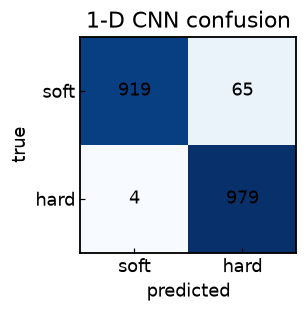

In [6]:
fig, ax = plt.subplots(figsize=(3.3, 3))
cm = confusion_matrix(yte, pred); ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["soft", "hard"]); ax.set_yticks([0, 1], ["soft", "hard"])
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("1-D CNN confusion")
for (i, j), v in np.ndenumerate(cm): ax.text(j, i, f"{v}", ha="center", va="center")
fig.tight_layout()

### ✅ Self-check
A quick sanity test that the numbers above came out sensible. If you edit the notebook and a result drifts badly, the cell below will stop with an `AssertionError` — a helpful early warning, not a bug.

In [7]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert acc_1d > 0.8, "the 1-D CNN on the raw curve should be accurate (it keeps magnitude)"
print("self-check passed ✓ — 1-D CNN kept the scale")

self-check passed ✓ — 1-D CNN kept the scale


## ✅ Recap
- A **1-D CNN** convolves filters along the raw curve — no image conversion needed.
- Because it **keeps magnitude**, it beats notebook 04's scale-invariant GAF CNN on this level-driven task.
- The lesson stands: **choose the representation that preserves whatever separates your classes** (shape → GAF; magnitude → raw 1-D or scalar features).

## 🔧 Try it yourself
Small changes teach the most. Try these (re-run the cell after each):
1. Rescale **each curve individually** to [0, 1] before training (mimicking the GAF's scale-invariance). Does the 1-D CNN's accuracy fall back toward 0.70?
2. Shrink the filter width from 5 to 3. Does the accuracy change much?
3. Train for 60 epochs instead of 30. Has it already plateaued by 30?

## 🩹 Common errors & fixes
- **Shape error in Conv1d** → the input must be (batch, 1, length); that's what `X[:, None]` adds.
- **Accuracy stuck near 0.5** → the model may be under-trained; increase epochs or check the curves were standardised.
- **Result wobbles run-to-run** → neural-net randomness; the *conclusion* (raw 1-D beats GAF here) is stable.

---
**Next:** **`05_autoencoder_latent_space.ipynb`** — let a network learn its own compact coordinates for these curves.